Import important packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Loading data and changing missing data values to Null

In [2]:
df = pd.read_csv("data/train.csv")
# Remove ? with NULL
df = df.replace(r"^\s*\?\s*$", pd.NA, regex=True)
# Remove Unkown/Invalid with NULL
df = df.replace(r"^\s*Unknown/Invalid\s*$", pd.NA, regex=True)
# Remove empty values with NULL
df = df.replace(r"^\s*$", pd.NA, regex=True)

#----------------------------------
#Setting unkown values from IDS_mapping to NULL in train.csv

# From IDS_mapping.csv
ids_to_null = {
    "admission_type_id": [5, 6, 8],                 # Not Available, NULL, Not Mapped
    "discharge_disposition_id": [18, 25, 26],       # NULL, Not Mapped, Unknown/Invalid
    "admission_source_id": [9, 15, 17, 20, 21],     # Not Available, NULL, Not Mapped, Unknown/Invalid
}

for col, bad_codes in ids_to_null.items():
    df[col] = df[col].replace(bad_codes, pd.NA)



checking that data is gone

In [3]:
# Check that mapped ID placeholders are gone
print((df["admission_type_id"].isin([5,6,8])).sum())
print((df["discharge_disposition_id"].isin([18,25,26])).sum())
print((df["admission_source_id"].isin([9,15,17,20,21])).sum())

# Check key placeholder strings are gone
for c in ["weight","payer_code","medical_specialty","race","gender","diag_1","diag_2","diag_3"]:
    print(c, (df[c].astype(str).str.strip() == "?").sum(), (df[c].astype(str).str.strip() == "Unknown/Invalid").sum())


0
0
0
weight 0 0
payer_code 0 0
medical_specialty 0 0
race 0 0
gender 0 0
diag_1 0 0
diag_2 0 0
diag_3 0 0


# checking information on features

In [4]:

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71236 entries, 0 to 71235
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        71236 non-null  int64 
 1   encounter_id              71236 non-null  int64 
 2   patient_nbr               71236 non-null  int64 
 3   race                      69615 non-null  object
 4   gender                    71233 non-null  object
 5   age                       71236 non-null  object
 6   weight                    2250 non-null   object
 7   admission_type_id         64013 non-null  object
 8   discharge_disposition_id  67917 non-null  object
 9   admission_source_id       66359 non-null  object
 10  time_in_hospital          71236 non-null  int64 
 11  payer_code                43058 non-null  object
 12  medical_specialty         36306 non-null  object
 13  num_lab_procedures        71236 non-null  int64 
 14  num_procedures        

,id,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,71236.000000,7.123600e+04,7.123600e+04,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000
mean,50874.217250,1.651772e+08,5.421577e+07,4.394660,43.112612,1.342523,16.016452,0.371104,0.195800,0.635353,7.418103
std,29423.014266,1.027123e+08,3.866893e+07,2.979942,19.658896,1.705587,8.130801,1.269937,0.864571,1.269287,1.930480
min,2.000000,1.573800e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,25319.750000,8.471072e+07,2.340213e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,50867.500000,1.523227e+08,4.520375e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,76450.250000,2.307948e+08,8.742009e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,101766.000000,4.438672e+08,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,63.000000,19.000000,16.000000


# cleaning of data

Inspecting missing values

In [5]:
# print Missing % in each feature
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print ("Missing % of data in features")
print(missing_pct.head(20))

# print Low-variance (few unique values)
nunique = df.nunique(dropna=False).sort_values()
print(nunique.head(20))

Missing % of data in features
weight                      96.841485
max_glu_serum               94.776517
A1Cresult                   83.323039
medical_specialty           49.034196
payer_code                  39.555843
admission_type_id           10.139536
admission_source_id          6.846258
discharge_disposition_id     4.659161
race                         2.275535
diag_3                       1.388343
diag_2                       0.342523
diag_1                       0.021057
gender                       0.004211
num_lab_procedures           0.000000
age                          0.000000
time_in_hospital             0.000000
patient_nbr                  0.000000
id                           0.000000
encounter_id                 0.000000
number_inpatient             0.000000
dtype: float64
examide                     1
citoglipton                 1
troglitazone                1
acetohexamide               2
tolbutamide                 2
metformin-pioglitazone      2
glimepiride-pio

cleaning of data

In [6]:
# --- Step 1: Drop unnecessary columns ---
df = df.drop(columns=[
    "payer_code",
    "id",
    "diag_1",
    "diag_2",
    "diag_3",
], errors="ignore")

# Dropping features with too many missing values
df = df.drop(columns=[
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
], errors="ignore")

# Dropping features with no variation
df = df.drop(columns=[
    "troglitazone",
    "examide",
    "citoglipton",
], errors="ignore")

# Dropping near-zero variance medication columns
df = df.drop(columns=[
    "acetohexamide",
    "glipizide-metformin",
    "tolbutamide",
    "metformin-pioglitazone",
    "metformin-rosiglitazone",
    "glimepiride-pioglitazone",
    "tolazamide",
], errors="ignore")

# --- Step 2: Remove expired/hospice patients ---
# Convert to numeric first since column is stored as string
df["discharge_disposition_id"] = pd.to_numeric(df["discharge_disposition_id"], errors="coerce")
# From IDS_mapping.csv: 11=Expired, 13=Hospice/home, 14=Hospice/facility,
#                       19=Expired at home, 20=Expired in facility, 21=Expired unknown
before = len(df)
df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])]
print(f"Rows removed (expired/hospice): {before - len(df)}")

# --- Step 3: Engineer history feature (needs patient_nbr and encounter_id) ---
df = df.sort_values(["patient_nbr", "encounter_id"])
df["previously_readmitted"] = (
    df.groupby("patient_nbr").cumcount() > 0
).astype(int)

# --- Step 4: Drop identifiers ---
df = df.drop(columns=["patient_nbr", "encounter_id"])

# --- Step 5: Handle missing values ---
df = df.dropna(subset=["gender"])
for col in ["admission_type_id", "admission_source_id", "discharge_disposition_id", "race"]:
    df[col] = df[col].fillna("Unknown").astype(str)

# --- Verify ---
print(f"Rows remaining: {len(df)}")
print(f"Missing values remaining:\n{df.isna().sum()[df.isna().sum() > 0]}")
print(f"\npreviously_readmitted value counts:\n{df['previously_readmitted'].value_counts()}")

Rows removed (expired/hospice): 1700
Rows remaining: 69533
Missing values remaining:
Series([], dtype: int64)

previously_readmitted value counts:
previously_readmitted
0    52972
1    16561
Name: count, dtype: int64


removing unsuable features

In [7]:

# print Missing % in each feature
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print ("Missing % of data in features")
print(missing_pct.head(20))

# print Low-variance (few unique values)
nunique = df.nunique(dropna=False).sort_values()
print(nunique.head(20))


Missing % of data in features
race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_outpatient           0.0
number_emergency            0.0
number_inpatient            0.0
number_diagnoses            0.0
metformin                   0.0
repaglinide                 0.0
nateglinide                 0.0
chlorpropamide              0.0
glimepiride                 0.0
glipizide                   0.0
dtype: float64
gender                   2
change                   2
previously_readmitted    2
diabetesMed              2
chlorpropamide           3
readmitted               3
repaglinide              4
metformin                4
glipizide                4
glimepiride              4
nateglinide              4
glyburide-metformi

# encoding of data

In [8]:
# --- Ordinal encoding for age ---
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df['age'] = pd.Categorical(df['age'], categories=age_order, ordered=True).codes

# --- Binary encoding ---
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['change'] = df['change'].map({'No': 0, 'Ch': 1})
df['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1})

# --- Target encoding ---
# we just care about readmitted not how long time between them
df['readmitted'] = df['readmitted'].map({'No': 0, '>30': 1, '<30': 1})

# --- One-hot encoding for nominal categoricals ---
# ensuring that we don't say race < other race or such in this medical context, so we keep all dummies (drop_first=False)
df = pd.get_dummies(df, columns=[
    'race',
    'admission_type_id',
    'admission_source_id',
    'discharge_disposition_id',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
    'glyburide-metformin'
], drop_first=False)

# --- Verify ---
print(f"Shape after encoding: {df.shape}")
print(f"Remaining non-numeric columns:\n{df.select_dtypes(include='object').columns.tolist()}")
print(f"\nSample of columns:\n{df.columns.tolist()}")

Shape after encoding: (69533, 112)
Remaining non-numeric columns:
[]

Sample of columns:
['gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'readmitted', 'previously_readmitted', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'admission_type_id_1', 'admission_type_id_2', 'admission_type_id_3', 'admission_type_id_4', 'admission_type_id_7', 'admission_type_id_Unknown', 'admission_source_id_1', 'admission_source_id_10', 'admission_source_id_11', 'admission_source_id_13', 'admission_source_id_14', 'admission_source_id_2', 'admission_source_id_22', 'admission_source_id_25', 'admission_source_id_3', 'admission_source_id_4', 'admission_source_id_5', 'admission_source_id_6', 'admission_source_id_7', 'admission_source_id_8', 'admission_source_id_Unknown', 'discharge_disposition_id_1.0', 'di

# Finding the features for model

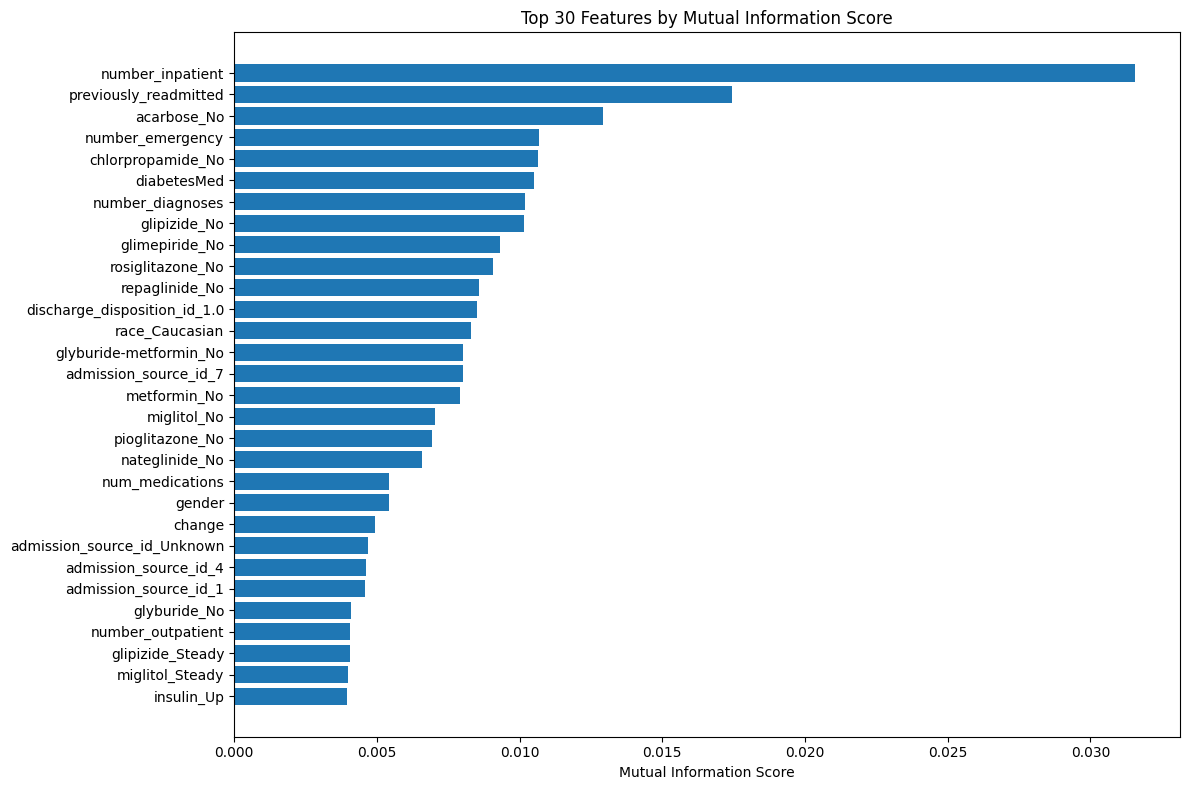


All feature scores:
number_inpatient                    0.031561
previously_readmitted               0.017436
acarbose_No                         0.012940
number_emergency                    0.010697
chlorpropamide_No                   0.010638
diabetesMed                         0.010523
number_diagnoses                    0.010202
glipizide_No                        0.010165
glimepiride_No                      0.009300
rosiglitazone_No                    0.009080
repaglinide_No                      0.008581
discharge_disposition_id_1.0        0.008508
race_Caucasian                      0.008289
glyburide-metformin_No              0.008030
admission_source_id_7               0.008024
metformin_No                        0.007904
miglitol_No                         0.007033
pioglitazone_No                     0.006917
nateglinide_No                      0.006571
num_medications                     0.005428
gender                              0.005419
change                            

In [9]:
from sklearn.feature_selection import mutual_info_classif

# Data is already fully encoded
y = df["readmitted"]
X = df.drop(columns=["readmitted"])

# Calculate mutual information scores for all features
scores = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=X.columns
).sort_values(ascending=False)

# Plot all feature scores
plt.figure(figsize=(12, 8))
plt.barh(scores.index[:30], scores.values[:30])  # top 30 for readability
plt.xlabel("Mutual Information Score")
plt.title("Top 30 Features by Mutual Information Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

pd.set_option('display.max_rows', None)
print("\nAll feature scores:")
print(scores)
pd.reset_option('display.max_rows')  # reset back to default after printing



In [10]:
## select feature with score above 0.003
selected_features = scores[scores > 0.003].index.tolist()
print(f"Selected {len(selected_features)} features")
print(selected_features)

Selected 35 features
['number_inpatient', 'previously_readmitted', 'acarbose_No', 'number_emergency', 'chlorpropamide_No', 'diabetesMed', 'number_diagnoses', 'glipizide_No', 'glimepiride_No', 'rosiglitazone_No', 'repaglinide_No', 'discharge_disposition_id_1.0', 'race_Caucasian', 'glyburide-metformin_No', 'admission_source_id_7', 'metformin_No', 'miglitol_No', 'pioglitazone_No', 'nateglinide_No', 'num_medications', 'gender', 'change', 'admission_source_id_Unknown', 'admission_source_id_4', 'admission_source_id_1', 'glyburide_No', 'number_outpatient', 'glipizide_Steady', 'miglitol_Steady', 'insulin_Up', 'age', 'insulin_Steady', 'insulin_No', 'admission_source_id_14', 'admission_type_id_2']


Remove medicine that is not taken.

In [11]:
selected_features = [
    # Strong numeric features
    'number_inpatient', 'previously_readmitted', 'number_emergency',
    'number_diagnoses', 'num_medications', 'number_outpatient', 'age',
    # Patient info
    'gender', 'race_Caucasian',
    # Admission info
    'discharge_disposition_id_1.0', 'admission_source_id_7',
    'admission_source_id_1', 'admission_source_id_4', 'admission_type_id_2',
    # Medication activity (actual usage, not absence)
    'insulin_Up', 'insulin_Steady', 'insulin_No',
    'glipizide_Steady', 'miglitol_Steady',
    # Other meaningful features
    'diabetesMed', 'change',
]

X = df[selected_features]
y = df["readmitted"]

print(f"X shape: {X.shape}")
print(f"y value counts:\n{y.value_counts()}")

X shape: (69533, 21)
y value counts:
readmitted
0    36758
1    32775
Name: count, dtype: int64


# Traning models

## Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

# Evaluate on validation set
best_lr = lr_grid.best_estimator_
best_lr_pred = best_lr.predict(X_val)
best_lr_prob = best_lr.predict_proba(X_val)[:, 1]

print(f"\nTuned Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_val, best_lr_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, best_lr_prob):.4f}")

Accuracy:  0.6211
ROC-AUC:   0.6658

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.78      0.68      7366
           1       0.64      0.45      0.53      6541

    accuracy                           0.62     13907
   macro avg       0.63      0.61      0.61     13907
weighted avg       0.62      0.62      0.61     13907



Feature coefficients (positive = increases readmission risk):
number_inpatient                0.354741
diabetesMed                     0.300006
previously_readmitted           0.245969
admission_source_id_7           0.236459
number_emergency                0.222799
race_Caucasian                  0.099167
admission_type_id_2             0.087952
glipizide_Steady                0.082150
number_outpatient               0.078836
number_diagnoses                0.076232
gender                          0.059087
admission_source_id_1           0.040877
age                             0.029630
num_medications                 0.002755
miglitol_Steady                 0.000904
discharge_disposition_id_1.0   -0.055078
change                         -0.057576
insulin_Up                     -0.085795
insulin_No                     -0.114485
insulin_Steady                 -0.215385
admission_source_id_4          -0.528668
dtype: float64


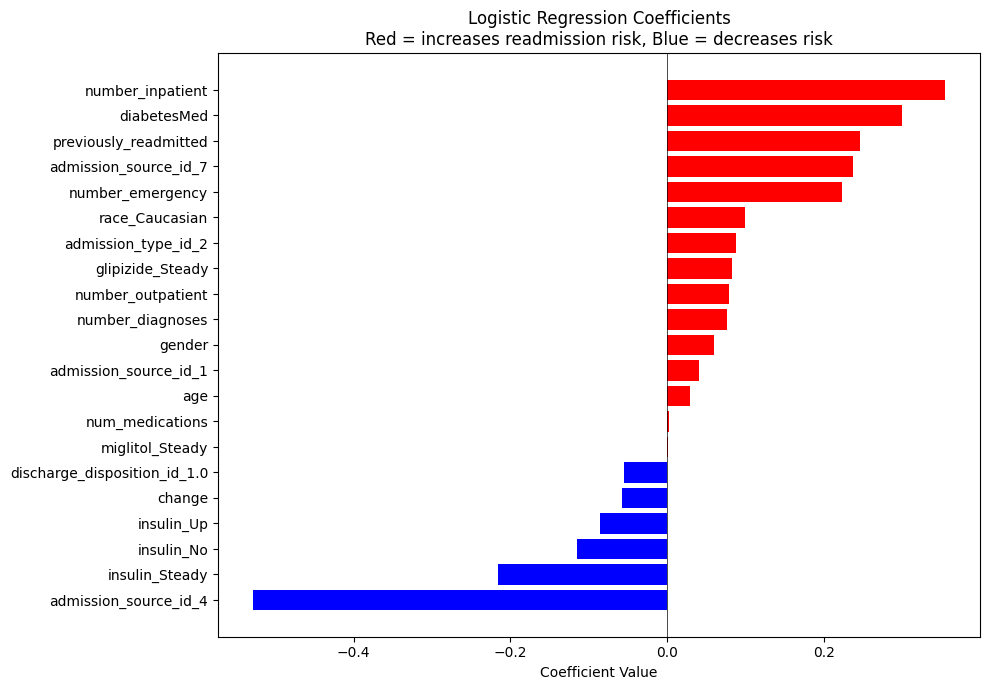

In [13]:
# Look at what the model learned
coefficients = pd.Series(
    model.coef_[0],
    index=selected_features
).sort_values(ascending=False)

print("Feature coefficients (positive = increases readmission risk):")
print(coefficients)

# Plot
plt.figure(figsize=(10, 7))
colors = ['red' if c > 0 else 'blue' for c in coefficients.values]
plt.barh(coefficients.index, coefficients.values, color=colors)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Coefficients\nRed = increases readmission risk, Blue = decreases risk")
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Random forrest

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X2_train, y2_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate best model on validation set
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X2_val)
best_rf_prob = best_rf.predict_proba(X2_val)[:, 1]

print(f"\nTuned Random Forest Results:")
print(f"Accuracy:  {accuracy_score(y2_val, best_rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y2_val, best_rf_prob):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.6851

Tuned Random Forest Results:
Accuracy:  0.6327
ROC-AUC:   0.6834


## K-Nearest_neighbour

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Use 21 features - better for KNN (less dimensionality)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)

# Evaluate
knn_pred = knn.predict(X_val_scaled)
knn_prob = knn.predict_proba(X_val_scaled)[:, 1]

print(f"KNN Results (21 features):")
print(f"Accuracy:  {accuracy_score(y_val, knn_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, knn_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, knn_pred))

KNN Results (21 features):
Accuracy:  0.5714
ROC-AUC:   0.5950

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.63      0.61      7366
           1       0.55      0.51      0.53      6541

    accuracy                           0.57     13907
   macro avg       0.57      0.57      0.57     13907
weighted avg       0.57      0.57      0.57     13907



## Decision tree

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV ROC-AUC: {dt_grid.best_score_:.4f}")

# Evaluate on validation set
best_dt = dt_grid.best_estimator_
best_dt_pred = best_dt.predict(X_val)
best_dt_prob = best_dt.predict_proba(X_val)[:, 1]

print(f"\nTuned Decision Tree Results:")
print(f"Accuracy:  {accuracy_score(y_val, best_dt_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, best_dt_prob):.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV ROC-AUC: 0.6592

Tuned Decision Tree Results:
Accuracy:  0.6222
ROC-AUC:   0.6572


Model                          Accuracy    ROC-AUC
Logistic Regression (21f)        0.6211     0.6658  ← best AUC
Decision Tree (21f)              0.6222     0.6572  ← best accuracy
Random Forest (54f)              0.6181     0.6617
Random Forest (21f)              0.5918     0.6232
KNN (21f)                        0.5714     0.5950